In [0]:
import pandas as pd 
#get relevant data during pyspark
orders = spark.sql("""
    select
      f.order_id, f.is_late, f.delivery_days, f.delay_days, f.promised_days,
      f.review_score, f.item_count, f.freight_total, f.items_total,
      f.purchased_at, c.state as customer_state
    from olist.gold.fact_orders f
    join olist.gold.dim_customer c on f.customer_id = c.customer_id
    where f.order_status = 'delivered'
      and f.delivered_at is not null
""").toPandas()

orders[["freight_total", "items_total"]] = orders[["freight_total", "items_total"]].astype(float)
orders["is_late"] = orders["is_late"].astype(bool) # have to convert Python decimal columns to pandas suitable for math
print(f"{len(orders):,} delivered orders") #the number of orders 

print(f"Late rate: {orders['is_late'].mean():.1%}") #round the percent mean of late orders to first decimal place
orders[["delivery_days", "delay_days", "promised_days", "review_score"]].describe().round(2)

96,470 delivered orders
Late rate: 6.8%


,delivery_days,delay_days,promised_days,review_score
count,96470.00,96470.00,96470.00,95824.00
mean,12.50,-11.88,24.37,4.16
std,9.56,10.18,8.76,1.28
min,0.00,-147.00,3.00,1.00
25%,7.00,-17.00,19.00,4.00
50%,10.00,-12.00,24.00,5.00
75%,16.00,-7.00,29.00,5.00
max,210.00,188.00,156.00,5.00


In [0]:
%sql
SELECT
  c.state,
  count(*)                                    AS orders,
  round(avg(cast(o.is_late AS int)) * 100, 1) AS pct_late,
  round(avg(o.review_score), 2)               AS avg_review
FROM olist.gold.fact_orders o
JOIN olist.gold.dim_customer c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.state
HAVING count(*) >= 500
ORDER BY pct_late DESC;


state,orders,pct_late,avg_review
MA,717,17.4,3.83
CE,1279,13.8,3.94
BA,3256,12.2,3.93
RJ,12350,12.1,3.97
PA,946,11.2,3.91
ES,1995,10.7,4.08
PB,517,10.4,4.08
MS,701,9.7,4.16
PE,1593,9.6,4.08
SC,3546,8.2,4.13


In [0]:
%sql
-- group by the month and check average orders delayed, what is the average review on those orders and only do months that have atleast 500 orders 
SELECT
  d.month_name                                   AS month,
  count(*)                                    AS orders,
  round(avg(cast(o.is_late AS int)) * 100, 1) AS pct_late,
  round(avg(o.review_score), 2)               AS avg_review
FROM olist.gold.fact_orders o
JOIN olist.gold.dim_date d ON o.purchase_date_key = d.date_key
WHERE o.order_status = 'delivered'
GROUP BY d.month_name
HAVING count(*) >= 500
ORDER BY pct_late DESC, month ASC;



month,orders,pct_late,avg_review
March,9549,15.1,3.91
November,7289,12.4,3.99
February,8208,11.9,3.95
December,5514,7.5,4.09
January,7819,5.4,4.12
May,10295,5.3,4.24
April,9101,5.0,4.19
August,10544,4.9,4.31
September,4151,4.4,4.27
October,4743,4.0,4.19


In [0]:
%sql 
-- group by product category and see which categories cause the most delays and low reviews. 
--which product category is most common in orders that are delayed
--one order can have multiple items, category is stored per item but lateness is on the order level so each order could potentially show up in 3 rows if it has 3 items if we join simply. (if items have same category).
-- so we can group the items in an order by their category 
-- one row per category per order.
-- then after, group by category for all orders and display reviews and lateness percent
WITH order_categories AS (
  SELECT DISTINCT
    i.order_id,
    p.category
  FROM olist.gold.fact_order_items i
  JOIN olist.gold.dim_product p ON i.product_id = p.product_id
)
SELECT
  oc.category,
  count(*)                                    AS orders,
  round(avg(cast(o.is_late AS int)) * 100, 1) AS pct_late,
  round(avg(o.review_score), 2)               AS avg_review
FROM order_categories oc
JOIN olist.gold.fact_orders o ON oc.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY oc.category
HAVING count(*) >= 500
ORDER BY pct_late DESC;

date_key,date_day,year,quarter,month,month_name,year_month,day_of_week,day_name,is_weekend
20160101,2016-01-01,2016,1,1,January,2016-01,6,Friday,false
20160102,2016-01-02,2016,1,1,January,2016-01,7,Saturday,true
20160103,2016-01-03,2016,1,1,January,2016-01,1,Sunday,true
20160104,2016-01-04,2016,1,1,January,2016-01,2,Monday,false
20160105,2016-01-05,2016,1,1,January,2016-01,3,Tuesday,false
20160106,2016-01-06,2016,1,1,January,2016-01,4,Wednesday,false
20160107,2016-01-07,2016,1,1,January,2016-01,5,Thursday,false
20160108,2016-01-08,2016,1,1,January,2016-01,6,Friday,false
20160109,2016-01-09,2016,1,1,January,2016-01,7,Saturday,true
20160110,2016-01-10,2016,1,1,January,2016-01,1,Sunday,true


In [0]:
%sql
--join fact_order_items on fact_orders on order_id. 
--keep one row per order, keep max of the distances of each item within the order
--then find the late rate and review score for each order, have groups for distance bands  
with order_distance AS (
    SELECT
        order_id,
        max(distance_km) AS km 
    FROM olist.gold.fact_order_items
    GROUP BY order_id
)
SELECT 
    CASE 
        WHEN od.km < 100 THEN '1: under 100 km'
        WHEN od.km < 500 THEN '2: 100-500 km'
        WHEN od.km < 1000 THEN '3: 500-1000 km'
        ELSE                   '4: 1000+ km'
    END                         AS distance_band,
    count(*)                    AS orders,
    round(avg(cast(o.is_late AS INT)) * 100, 1) AS pct_late,
    round(avg(o.review_score), 2) AS avg_review
FROM order_distance od
JOIN olist.gold.fact_orders o ON od.order_id = o.order_id
WHERE o.order_status = 'delivered'
    AND od.km IS NOT NULL
GROUP BY 1
ORDER BY 1;


distance_band,orders,pct_late,avg_review
1: under 100 km,17798,4.5,4.28
2: 100-500 km,36977,6.1,4.18
3: 500-1000 km,25834,7.1,4.11
4: 1000+ km,15392,10.4,4.02


In [0]:
# does lateness really affect reviews?
import pandas as pd
orders = spark.sql("""
                   select order_id, is_late, review_score
                   from olist.gold.fact_orders
                   where order_status = 'delivered'
                   and delivered_at is not null
                   """).toPandas()
orders["is_late"] = orders["is_late"].astype(bool)
print(f"{len(orders):,} delivered orders")

from scipy import stats

# Keep only orders that have a review
reviewed = orders.dropna(subset=["review_score"])

late   = reviewed.loc[reviewed["is_late"], "review_score"]
ontime = reviewed.loc[~reviewed["is_late"], "review_score"]

# 1. Basic comparison
print(f"Late:    n={len(late):,}  mean={late.mean():.2f}  median={late.median():.0f}")
print(f"On time: n={len(ontime):,}  mean={ontime.mean():.2f}  median={ontime.median():.0f}")

# 2. Mann-Whitney U test: are late orders' scores lower?
u = stats.mannwhitneyu(late, ontime, alternative="less")
effect = 2 * u.statistic / (len(late) * len(ontime)) - 1
print(f"\nMann-Whitney U p-value: {u.pvalue:.2e}")
print(f"Rank-biserial effect size: {effect:.2f}")

# 3. Chance of a bad (1–2 star) review
reviewed = reviewed.assign(low_review=reviewed["review_score"] <= 2)
rates = reviewed.groupby("is_late")["low_review"].mean()
table = pd.crosstab(reviewed["is_late"], reviewed["low_review"])
chi2, p, dof, _ = stats.chi2_contingency(table)

print(f"\nLow-review rate, on time: {rates[False]:.1%}")
print(f"Low-review rate, late:    {rates[True]:.1%}")
print(f"Relative risk: {rates[True] / rates[False]:.1f}x   (chi-square p = {p:.2e})")

96,470 delivered orders
Late:    n=6,381  mean=2.27  median=1
On time: n=89,443  mean=4.29  median=5

Mann-Whitney U p-value: 0.00e+00
Rank-biserial effect size: -0.64

Low-review rate, on time: 9.3%
Low-review rate, late:    62.4%
Relative risk: 6.7x   (chi-square p = 0.00e+00)


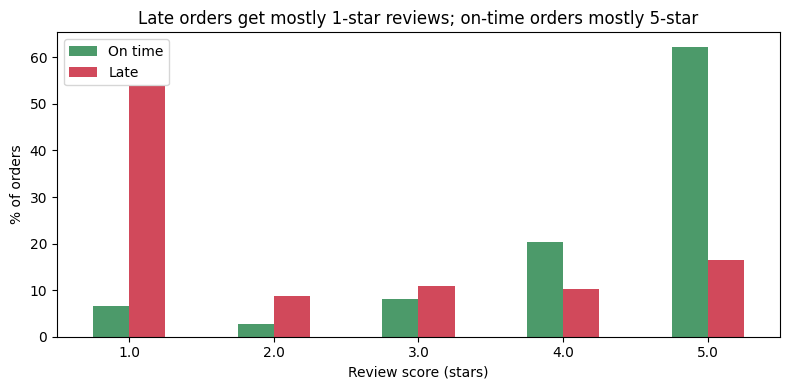

In [0]:
import matplotlib.pyplot as plt

dist = (reviewed.groupby("is_late")["review_score"]
        .value_counts(normalize=True)
        .unstack(0)
        .sort_index())
dist.columns = ["On time", "Late"]

ax = (dist * 100).plot(kind="bar", figsize=(8, 4), rot=0, color=["#4C9A6A", "#D1495B"])
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("% of orders")
ax.set_title("Late orders get mostly 1-star reviews; on-time orders mostly 5-star")
plt.tight_layout()
plt.show()

## Key findings

1. **Late deliveries sharply damage satisfaction.** Late orders average 2.3 stars vs. 4.3 for on-time orders (median 1 vs. 5) and are **6.7× more likely** to receive a 1–2 star review (62% vs. 9%). Significant with a large effect (Mann-Whitney U, p < 0.001, rank-biserial r = −0.64).

2. **Lateness is concentrated.** About 7% of orders are late, but they produce a disproportionate share of bad reviews. States [A, B] and categories [C, D] have the highest late rates, and lateness spikes in [month(s)].

3. **Distance drives delivery time.** Orders shipped 1,000+ km take [X] days on average vs. [Y] under 100 km, with late rates of [X%] vs. [Y%].

**Recommendation:** [e.g., set longer delivery estimates for long-distance and high-risk routes, and add logistics capacity ahead of peak months, targeting the small share of orders responsible for most negative reviews.]